# Regresión lineal: tiempo y precio de WTI y Brent

Se ajusta una recta por separado para WTI y Brent en cada período definido en el proyecto:

- **Período 1:** 01/01/2024 a 28/02/2026.
- **Período 2:** 01/04/2026 a la última cotización disponible en el CSV.

Marzo de 2026 queda excluido. Se utilizan los precios diarios de EIA en **USD por barril**. El objetivo es describir la tendencia temporal dentro de cada muestra.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import linregress

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Carga y validación de los precios

In [2]:
PROJECT_ROOT = next(
    (ruta for ruta in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (ruta / "data").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la carpeta data/ del proyecto.")

archivos_csv = list((PROJECT_ROOT / "data").glob("eia_precios_crudo_diarios_*.csv"))
if not archivos_csv:
    raise FileNotFoundError("No se encontró el CSV de precios diarios dentro de data/.")
CSV_PATH = max(archivos_csv, key=lambda ruta: ruta.stat().st_mtime)

df = pd.read_csv(CSV_PATH)
columnas_requeridas = {"period", "series", "value"}
faltantes = columnas_requeridas.difference(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas en el CSV: {sorted(faltantes)}")

df = df.loc[df["series"].isin(["RWTC", "RBRTE"])].copy()
df["period"] = pd.to_datetime(df["period"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
if df[["period", "series", "value"]].isna().any().any():
    raise ValueError("Hay fechas, series o precios inválidos en el CSV.")
if df.duplicated(["period", "series"]).any():
    raise ValueError("Hay más de un precio para alguna combinación de fecha y crudo.")
if not np.isfinite(df["value"]).all():
    raise ValueError("Hay precios no finitos en el CSV.")

print(f"Fuente: {CSV_PATH.name}")
print(f"Última cotización disponible: {df['period'].max():%d/%m/%Y}")
print(f"Registros válidos de WTI y Brent: {len(df):,}")

Fuente: eia_precios_crudo_diarios_2024-01_a_2026-09.csv
Última cotización disponible: 22/09/2026
Registros válidos de WTI y Brent: 1,368


## 2. Definición de la variable tiempo

Para cada combinación de período y crudo, **t = 0** corresponde a su primera cotización observada. Las fechas siguientes se expresan en **días calendario** desde esa fecha. No se inventan precios para fines de semana ni para días sin cotización.

La ecuación ajustada por mínimos cuadrados es **precio estimado = a + b·t**. El intercepto **a** se expresa en USD/barril y la pendiente **b** en USD/barril por día. **R** es la correlación de Pearson con signo entre tiempo y precio. **R²** es la proporción de variación del precio explicada por esta recta dentro de la muestra.

In [3]:
PERIODOS = {
    "Período 1": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-02-28")),
    "Período 2": (pd.Timestamp("2026-04-01"), df["period"].max()),
}
SERIES = {"WTI": "RWTC", "Brent": "RBRTE"}

filas = []
ajustes = {}
for periodo, (inicio, fin) in PERIODOS.items():
    for crudo, codigo in SERIES.items():
        muestra = df.loc[
            df["series"].eq(codigo) & df["period"].between(inicio, fin),
            ["period", "value"],
        ].sort_values("period").reset_index(drop=True)
        if len(muestra) < 3 or muestra["period"].nunique() < 2:
            raise ValueError(f"No hay fechas suficientes para ajustar {crudo} en {periodo}.")

        fecha_base = muestra["period"].min()
        t = (muestra["period"] - fecha_base).dt.days.to_numpy(dtype=float)
        precio = muestra["value"].to_numpy(dtype=float)
        ajuste = linregress(t, precio)
        predicho = ajuste.intercept + ajuste.slope * t
        r_cuadrado = 1 - np.sum((precio - predicho) ** 2) / np.sum((precio - precio.mean()) ** 2)
        np.testing.assert_allclose(r_cuadrado, ajuste.rvalue**2, atol=1e-12)

        ajustes[(periodo, crudo)] = (muestra, fecha_base, ajuste)
        filas.append({
            "Período": periodo,
            "Crudo": crudo,
            "Desde": muestra["period"].min().strftime("%d/%m/%Y"),
            "Hasta": muestra["period"].max().strftime("%d/%m/%Y"),
            "n": len(muestra),
            "Ecuación (t en días)": f"ŷ = {ajuste.intercept:.3f} {ajuste.slope:+.5f}·t",
            "R": ajuste.rvalue,
            "R²": r_cuadrado,
            "Pendiente": ajuste.slope,
        })

resultados = pd.DataFrame(filas)
display(resultados.drop(columns="Pendiente").style.format({"R": "{:.3f}", "R²": "{:.3f}"}))

,Período,Crudo,Desde,Hasta,n,Ecuación (t en días),R,R²
0,Período 1,WTI,02/01/2024,27/02/2026,537,ŷ = 81.981 -0.02954·t,-0.857,0.734
1,Período 1,Brent,02/01/2024,27/02/2026,547,ŷ = 85.687 -0.02877·t,-0.848,0.719
2,Período 2,WTI,01/04/2026,22/09/2026,120,ŷ = 98.657 -0.08606·t,-0.385,0.149
3,Período 2,Brent,01/04/2026,22/09/2026,120,ŷ = 106.409 -0.08993·t,-0.278,0.077


## 3. Precios observados y rectas ajustadas

Los puntos muestran todas las cotizaciones disponibles. La línea representa la recta ajustada sobre las fechas observadas, sin extrapolar fuera de cada período.

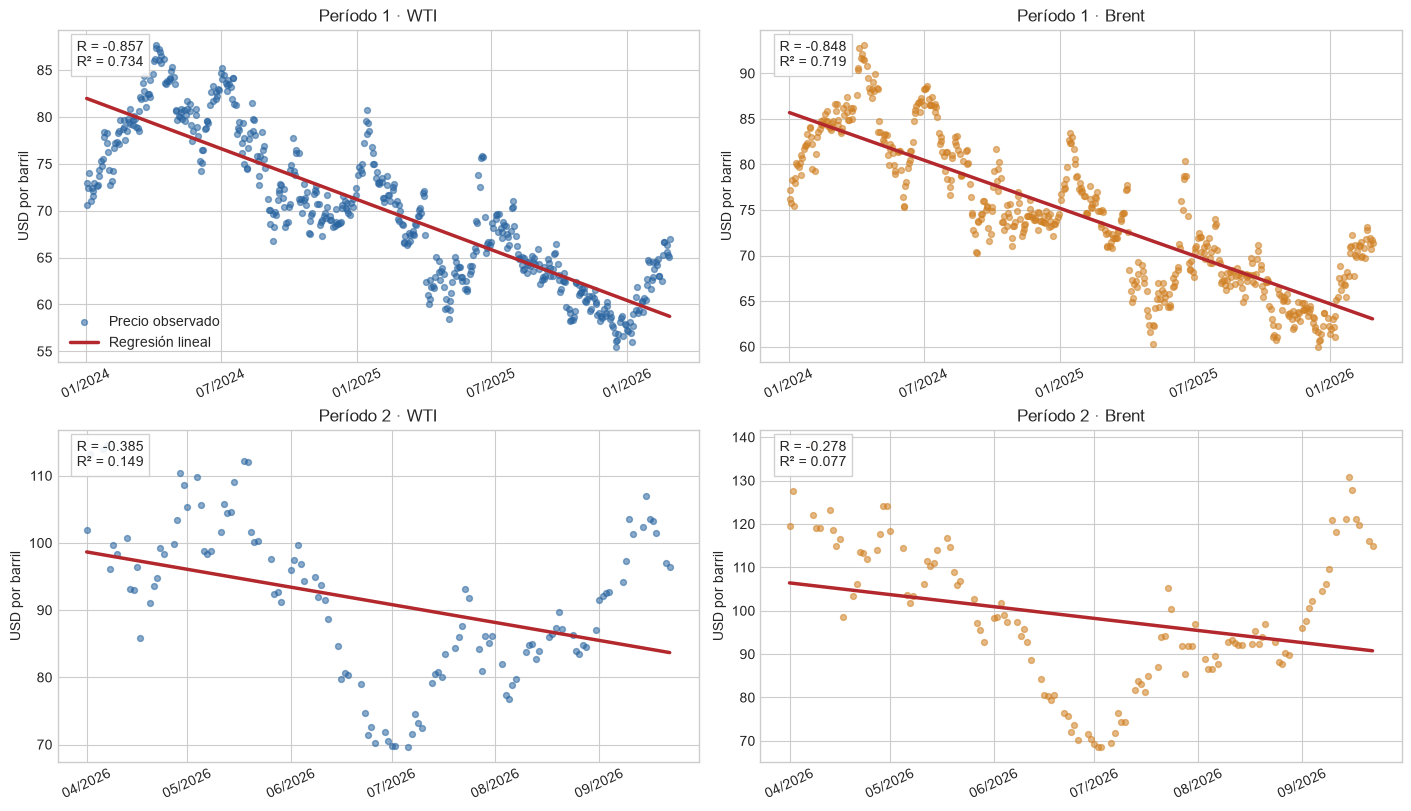

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
colores = {"WTI": "#2864A0", "Brent": "#D08023"}

for fila, periodo in enumerate(PERIODOS):
    for columna, crudo in enumerate(SERIES):
        ax = axes[fila, columna]
        muestra, fecha_base, ajuste = ajustes[(periodo, crudo)]
        t = (muestra["period"] - fecha_base).dt.days.to_numpy(dtype=float)
        ax.scatter(muestra["period"], muestra["value"], s=18, alpha=0.55,
                   color=colores[crudo], label="Precio observado")
        ax.plot(muestra["period"], ajuste.intercept + ajuste.slope * t,
                color="#B3282D", linewidth=2.5, label="Regresión lineal")
        ax.set_title(f"{periodo} · {crudo}")
        ax.set_ylabel("USD por barril")
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=7))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
        ax.tick_params(axis="x", rotation=25)
        ax.text(0.03, 0.97, f"R = {ajuste.rvalue:.3f}\nR² = {ajuste.rvalue**2:.3f}",
                transform=ax.transAxes, va="top", ha="left",
                bbox={"facecolor": "white", "edgecolor": "#CCCCCC", "alpha": 0.9})
        if fila == 0 and columna == 0:
            ax.legend(loc="lower left")

plt.show()

## 4. Lectura de los resultados

In [5]:
for periodo in PERIODOS:
    resumen = resultados.loc[resultados["Período"].eq(periodo)].set_index("Crudo")
    wti, brent = resumen.loc["WTI"], resumen.loc["Brent"]
    display(Markdown(
        f"**{periodo}.** La pendiente es negativa para WTI "
        f"({wti['Pendiente']:.3f} USD/barril por día) y Brent "
        f"({brent['Pendiente']:.3f} USD/barril por día): ambos muestran una "
        f"tendencia lineal descendente en estas fechas. La recta explica "
        f"{wti['R²']:.1%} de la variación observada de WTI y "
        f"{brent['R²']:.1%} de la de Brent."
    ))

**Período 1.** La pendiente es negativa para WTI (-0.030 USD/barril por día) y Brent (-0.029 USD/barril por día): ambos muestran una tendencia lineal descendente en estas fechas. La recta explica 73.4% de la variación observada de WTI y 71.9% de la de Brent.

**Período 2.** La pendiente es negativa para WTI (-0.086 USD/barril por día) y Brent (-0.090 USD/barril por día): ambos muestran una tendencia lineal descendente en estas fechas. La recta explica 14.9% de la variación observada de WTI y 7.7% de la de Brent.

**Alcance.** R negativo indica que precios más bajos se asocian con fechas posteriores. En el período 1, la recta resume bastante bien la tendencia general. En el período 2, los precios caen y luego se recuperan: una recta explica poco de esa trayectoria, especialmente en Brent. R² mide el ajuste dentro de la muestra y no garantiza pronósticos futuros. Estos son ajustes descriptivos; las series temporales pueden tener autocorrelación y cambios de régimen.